# Figure1 (Model Map with Sampling Error)

In [1]:
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.visualization import adjust, lighter
from src.ellipse import map_centrography
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
tsne_Q = pickle.load(open('data/tsne_Q.pkl', 'rb'))
modeldata = pickle.load(open('data/modeldata_1018.pkl', 'rb'))
type_color = pickle.load(open('data/color/modeltype.pkl', 'rb'))
map_variance = pickle.load(open('./data/fig3a_mapvariance.pkl', 'rb'))
tsne100 = map_variance['tsne_uni_10000_R100']

def get_plotdata(tsne_points, ellipses):
    plot_data = {
        'points': {
            'others': {'x': [], 'y': [], 'color': [], 'model_names': []},
            'show': {}
        },
        'ellipses': ellipses
    }
    for md in modeldata:
        model_name = md['model_name']
        model_type = md['modeltype_fig1']
        coords = tsne_points[model_name]
        if model_type == 'others':
            color = type_color['others']
            plot_data['points']['others']['x'].append(coords[0])
            plot_data['points']['others']['y'].append(coords[1])
            plot_data['points']['others']['color'].append(color)
            plot_data['points']['others']['model_names'].append(model_name)
            plot_data['ellipses'][model_name]['xy'] = coords
            plot_data['ellipses'][model_name]['color'] = color
        else:
            color = type_color[model_type]
            if model_type not in plot_data['points']['show']:
                plot_data['points']['show'][model_type] = {'x': [], 'y': [], 'color': [], 'model_names': [], 'label': model_type}
            plot_data['points']['show'][model_type]['x'].append(coords[0])
            plot_data['points']['show'][model_type]['y'].append(coords[1])
            plot_data['points']['show'][model_type]['color'].append(color)
            plot_data['points']['show'][model_type]['model_names'].append(model_name)
            plot_data['ellipses'][model_name]['xy'] = coords
            plot_data['ellipses'][model_name]['color'] = color
    return plot_data

points, ellipses = map_centrography(tsne100, ref_tsne_data=tsne_Q)
plot_data = get_plotdata(points, ellipses)

In [3]:
def scatter_and_ellipse(ax, plot_data):
    points = plot_data['points']
    ellipses = plot_data['ellipses']
    ax.scatter(
        points['others']['x'], points['others']['y'], c=points['others']['color'],
        s=18, alpha=1, zorder=1, rasterized=True
    )
    for model_type, data in points['show'].items():
        ax.scatter(
            data['x'], data['y'], c=data['color'],
            s=18, alpha=1, zorder=2, rasterized=True
        )
    for model_name, ellipse in tqdm(ellipses.items()):
        ellipse_shape = Ellipse(
            xy=ellipse['xy'],
            width=ellipse['width'],
            height=ellipse['height'],
            angle=ellipse['angle'],
            facecolor=lighter(ellipse['color'], 0.15),
            alpha=0.6,
            zorder=0,
            rasterized=True
        )
        ax.add_patch(ellipse_shape)

100%|██████████| 1018/1018 [00:00<00:00, 1299.90it/s]
/var/folders/5k/k5byyl096_xdbdcd4jggw9_40000gn/T/ipykernel_46233/1862100012.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handle = ax_figure.scatter([], [], s=marksize['legend'], c=color_code, label=modeltype_name)


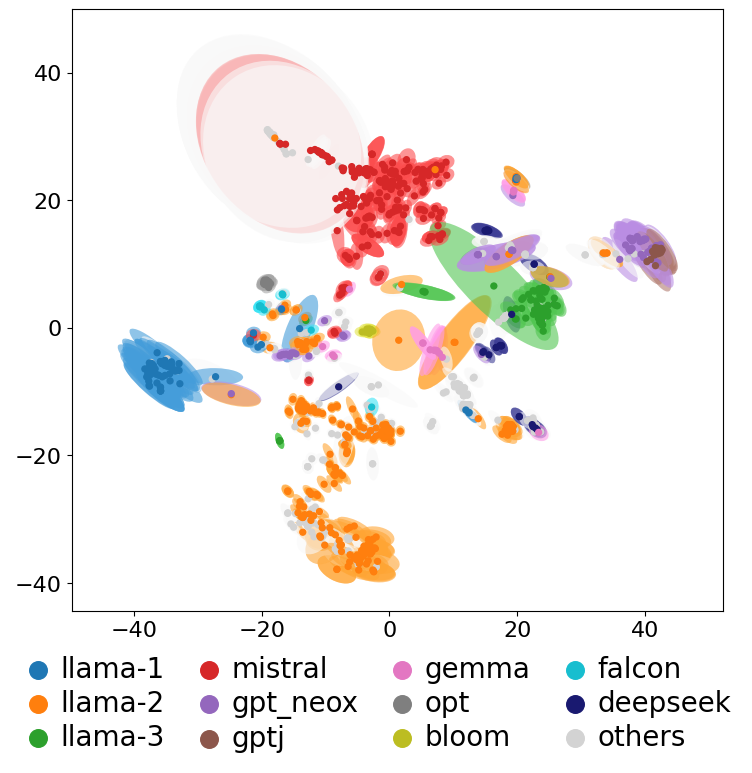

In [4]:
figure = plt.figure(figsize=(7.2, 7.5))
gs_master = GridSpec(nrows=2, ncols=1, height_ratios=[72, 3])
gs_legend = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[1])
ax_legend = figure.add_subplot(gs_legend[0])
ax_legend.set_axis_off()
gs_figure = GridSpecFromSubplotSpec(nrows=1, ncols=1, subplot_spec=gs_master[0])
ax_figure = figure.add_subplot(gs_figure[0])
ax_figure.set_aspect('equal', adjustable='datalim')

fonts = {
    'title': 24,
    'legend': 20,
}

marksize = {
    '1_others': 16,
    '1_show': 16,
    'legend': 160
}

scatter_and_ellipse(ax_figure, plot_data)
ax_figure.tick_params(axis='x', labelsize=16)
ax_figure.tick_params(axis='y', labelsize=16)

legend_handles = []
for modeltype_name, color_code in type_color.items():
    handle = ax_figure.scatter([], [], s=marksize['legend'], c=color_code, label=modeltype_name)
    legend_handles.append(handle)

ax_legend.legend(
    handles=legend_handles, 
    labels=[h.get_label() for h in legend_handles], 
    ncol=4, 
    fontsize=fonts['legend'], 
    columnspacing=1,
    labelspacing=0.2,
    handletextpad=0.2,
    handlelength=1.2,
    loc='center',
    frameon=False,
)

adjust(ax_figure, dx=-0.045, dy=-0.02, dw=0.13, dh=0.13)
adjust(ax_legend, dx=-0.01, dy=-0.06, dw=0, dh=0)
plt.savefig('./figures/fig1.png', dpi=300)
plt.savefig('./figures/fig1.pdf', format='pdf', dpi=300)